# Prediction Intervals and Uncertainty for Short-Term Estimated WEC Power Forecasts

This notebook extends the short-term point-forecasting baselines from [Notebook 03](03_forecasting_baselines.ipynb) by evaluating prediction intervals for the estimated WEC power signal.

Notebook 03 focused on point forecasts for the normalized estimated WEC power target, `wec_power_norm_estimated`, using a compact power-only autoregressive benchmark. The saved calibration and test predictions from that notebook provide the residual basis for the uncertainty analysis here.

The goal of this notebook is to evaluate whether simple empirical prediction intervals provide useful uncertainty estimates across forecast horizons, models, and higher-ramp periods. The main evaluation remains on the normalized WEC-power scale, while selected 250 kW-scale values are used later for physical interpretation of the generic WEC proxy.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown


# Paths are relative to the notebooks/ directory.
NOTEBOOK_ID = "notebook_04"

DATA_DIR = Path("../data")
OUTPUTS_DIR = Path("../outputs")

INPUT_FORECAST_PATH = OUTPUTS_DIR / "notebook_03" / "forecast_predictions.parquet"
INPUT_FOLDS_PATH = DATA_DIR / "processed" / "folds" / "forecast_folds.parquet"

TABLES_DIR = OUTPUTS_DIR / "tables" / NOTEBOOK_ID
FIGURES_DIR = OUTPUTS_DIR / "figures" / NOTEBOOK_ID
NOTEBOOK_OUTPUT_DIR = OUTPUTS_DIR / NOTEBOOK_ID

for path in [TABLES_DIR, FIGURES_DIR, NOTEBOOK_OUTPUT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

RATED_POWER_KW = 250.0

INTERVAL_LEVELS = [0.80, 0.90, 0.95]
MAIN_INTERVAL_LEVEL = 0.90

PRIMARY_MODELS = ["Persistence", "RollingMean", "Ridge"]
CONTRAST_MODELS = ["RandomForest"]
ALL_MODELS = PRIMARY_MODELS + CONTRAST_MODELS

## Notebook 03 forecast outputs and analysis scope

Prediction intervals are built from the selected calibration and test predictions saved by [Notebook 03](03_forecasting_baselines.ipynb).

The calibration split is used to estimate residual-based interval rules. The test split is reserved for final prediction-interval evaluation. The main analysis focuses on Persistence, RollingMean, and Ridge, while RandomForest is retained only as a contrast model because it was slower and not competitive in the point-forecast benchmark.

In [3]:
forecast_df = pd.read_parquet(INPUT_FORECAST_PATH)
folds_df = pd.read_parquet(INPUT_FOLDS_PATH)

required_columns = [
    "sample_id",
    "origin_time",
    "target_time",
    "horizon_steps",
    "horizon_hours",
    "horizon_label",
    "fold_id",
    "split",
    "model",
    "y_true_norm",
    "y_pred_norm",
    "error_norm",
    "y_true_kw_250",
    "y_pred_kw_250",
    "error_kw_250",
]

missing_columns = sorted(set(required_columns) - set(forecast_df.columns))
if missing_columns:
    raise ValueError(f"Missing required columns in forecast predictions: {missing_columns}")

forecast_df = forecast_df[required_columns].copy()

forecast_df["origin_time"] = pd.to_datetime(forecast_df["origin_time"])
forecast_df["target_time"] = pd.to_datetime(forecast_df["target_time"])

forecast_df = forecast_df[
    forecast_df["split"].isin(["calibration", "test"])
    & forecast_df["model"].isin(ALL_MODELS)
].copy()

forecast_df = forecast_df.sort_values(
    ["horizon_steps", "fold_id", "split", "model", "target_time"]
).reset_index(drop=True)

forecast_df["abs_error_norm"] = forecast_df["error_norm"].abs()

print(f"Loaded forecast predictions: {forecast_df.shape[0]:,} rows")
print(f"Loaded fold definitions: {folds_df.shape[0]:,} rows")

Loaded forecast predictions: 102,396 rows
Loaded fold definitions: 85,299 rows


In [4]:
input_summary = (
    forecast_df
    .groupby(["horizon_steps", "horizon_label", "model", "split"], observed=True)
    .agg(
        n_rows=("sample_id", "size"),
        first_target_time=("target_time", "min"),
        last_target_time=("target_time", "max"),
    )
    .reset_index()
)

input_summary_path = TABLES_DIR / "interval_input_summary.csv"
input_summary.to_csv(input_summary_path, index=False)

display(Markdown("**Notebook 04 input rows by horizon, model, and split**"))
display(Markdown(input_summary.to_markdown(index=False)))

print(f"Saved input summary to: {input_summary_path}")

**Notebook 04 input rows by horizon, model, and split**

|   horizon_steps | horizon_label   | model        | split       |   n_rows | first_target_time   | last_target_time    |
|----------------:|:----------------|:-------------|:------------|---------:|:--------------------|:--------------------|
|               1 | 30 min          | Persistence  | calibration |     3281 | 2025-04-18 16:00:00 | 2025-06-13 12:00:00 |
|               1 | 30 min          | Persistence  | test        |     3289 | 2025-05-08 03:00:00 | 2025-06-30 23:30:00 |
|               1 | 30 min          | RandomForest | calibration |     3281 | 2025-04-18 16:00:00 | 2025-06-13 12:00:00 |
|               1 | 30 min          | RandomForest | test        |     3289 | 2025-05-08 03:00:00 | 2025-06-30 23:30:00 |
|               1 | 30 min          | Ridge        | calibration |     3281 | 2025-04-18 16:00:00 | 2025-06-13 12:00:00 |
|               1 | 30 min          | Ridge        | test        |     3289 | 2025-05-08 03:00:00 | 2025-06-30 23:30:00 |
|               1 | 30 min          | RollingMean  | calibration |     3281 | 2025-04-18 16:00:00 | 2025-06-13 12:00:00 |
|               1 | 30 min          | RollingMean  | test        |     3289 | 2025-05-08 03:00:00 | 2025-06-30 23:30:00 |
|               2 | 1 h             | Persistence  | calibration |     3250 | 2025-04-18 15:30:00 | 2025-06-13 13:30:00 |
|               2 | 1 h             | Persistence  | test        |     3258 | 2025-05-08 03:30:00 | 2025-06-30 23:30:00 |
|               2 | 1 h             | RandomForest | calibration |     3250 | 2025-04-18 15:30:00 | 2025-06-13 13:30:00 |
|               2 | 1 h             | RandomForest | test        |     3258 | 2025-05-08 03:30:00 | 2025-06-30 23:30:00 |
|               2 | 1 h             | Ridge        | calibration |     3250 | 2025-04-18 15:30:00 | 2025-06-13 13:30:00 |
|               2 | 1 h             | Ridge        | test        |     3258 | 2025-05-08 03:30:00 | 2025-06-30 23:30:00 |
|               2 | 1 h             | RollingMean  | calibration |     3250 | 2025-04-18 15:30:00 | 2025-06-13 13:30:00 |
|               2 | 1 h             | RollingMean  | test        |     3258 | 2025-05-08 03:30:00 | 2025-06-30 23:30:00 |
|               4 | 2 h             | Persistence  | calibration |     3189 | 2025-04-18 13:30:00 | 2025-06-13 16:30:00 |
|               4 | 2 h             | Persistence  | test        |     3195 | 2025-05-08 03:00:00 | 2025-06-30 23:30:00 |
|               4 | 2 h             | RandomForest | calibration |     3189 | 2025-04-18 13:30:00 | 2025-06-13 16:30:00 |
|               4 | 2 h             | RandomForest | test        |     3195 | 2025-05-08 03:00:00 | 2025-06-30 23:30:00 |
|               4 | 2 h             | Ridge        | calibration |     3189 | 2025-04-18 13:30:00 | 2025-06-13 16:30:00 |
|               4 | 2 h             | Ridge        | test        |     3195 | 2025-05-08 03:00:00 | 2025-06-30 23:30:00 |
|               4 | 2 h             | RollingMean  | calibration |     3189 | 2025-04-18 13:30:00 | 2025-06-13 16:30:00 |
|               4 | 2 h             | RollingMean  | test        |     3195 | 2025-05-08 03:00:00 | 2025-06-30 23:30:00 |
|               8 | 4 h             | Persistence  | calibration |     3065 | 2025-04-18 11:00:00 | 2025-06-14 15:00:00 |
|               8 | 4 h             | Persistence  | test        |     3072 | 2025-05-08 03:30:00 | 2025-06-30 23:30:00 |
|               8 | 4 h             | RandomForest | calibration |     3065 | 2025-04-18 11:00:00 | 2025-06-14 15:00:00 |
|               8 | 4 h             | RandomForest | test        |     3072 | 2025-05-08 03:30:00 | 2025-06-30 23:30:00 |
|               8 | 4 h             | Ridge        | calibration |     3065 | 2025-04-18 11:00:00 | 2025-06-14 15:00:00 |
|               8 | 4 h             | Ridge        | test        |     3072 | 2025-05-08 03:30:00 | 2025-06-30 23:30:00 |
|               8 | 4 h             | RollingMean  | calibration |     3065 | 2025-04-18 11:00:00 | 2025-06-14 15:00:00 |
|               8 | 4 h             | RollingMean  | test        |     3072 | 2025-05-08 03:30:00 | 2025-06-30 23:30:00 |

Saved input summary to: ../outputs/tables/notebook_04/interval_input_summary.csv


## Residual basis for interval calibration

Notebook 04 uses the calibration residuals saved by Notebook 03 as the empirical basis for prediction intervals. Before constructing intervals, the calibration residual spread is visualized by model and forecast horizon.

This provides a simple check of whether interval widths should depend on horizon and model choice.

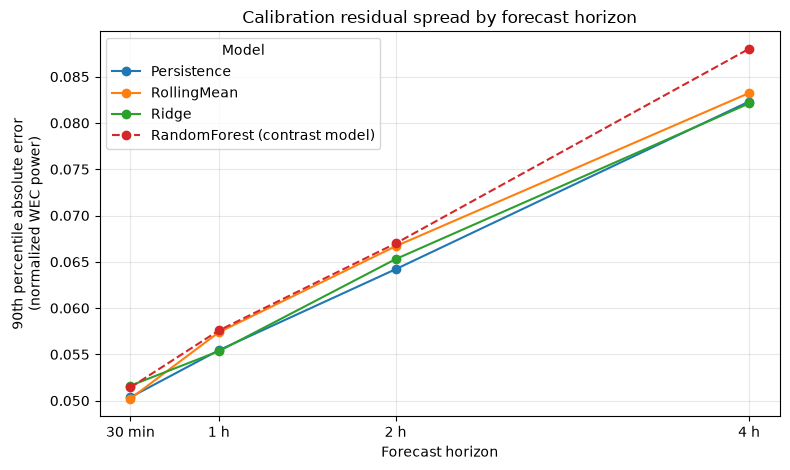

Saved calibration residual spread figure to: ../outputs/figures/notebook_04/calibration_residual_spread_by_horizon.png


In [8]:
plot_df = (
    forecast_df
    .query("split == 'calibration'")
    .groupby(
        ["horizon_steps", "horizon_hours", "horizon_label", "model"],
        observed=True,
    )
    .agg(
        p90_abs_error_norm=("abs_error_norm", lambda x: np.quantile(x.dropna(), 0.90))
    )
    .reset_index()
)

horizon_ticks = (
    plot_df[["horizon_hours", "horizon_label"]]
    .drop_duplicates()
    .sort_values("horizon_hours")
)

fig, ax = plt.subplots(figsize=(8, 4.8))

for model in ALL_MODELS:
    model_df = plot_df[plot_df["model"].eq(model)].sort_values("horizon_steps")
    if model_df.empty:
        continue

    is_contrast = model in CONTRAST_MODELS
    linestyle = "--" if is_contrast else "-"
    label = f"{model} (contrast model)" if is_contrast else model

    ax.plot(
        model_df["horizon_hours"],
        model_df["p90_abs_error_norm"],
        marker="o",
        linestyle=linestyle,
        label=label,
    )

ax.set_title("Calibration residual spread by forecast horizon")
ax.set_xlabel("Forecast horizon")
ax.set_ylabel("90th percentile absolute error\n(normalized WEC power)")
ax.set_xticks(horizon_ticks["horizon_hours"])
ax.set_xticklabels(horizon_ticks["horizon_label"])
ax.grid(True, alpha=0.3)
ax.legend(title="Model")

fig.tight_layout()

residual_spread_path = FIGURES_DIR / "calibration_residual_spread_by_horizon.png"
fig.savefig(residual_spread_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved calibration residual spread figure to: {residual_spread_path}")

## Build prediction intervals

Prediction intervals are constructed from the calibration residuals saved by Notebook 03 and then applied to the test predictions.

The three core methods below are deliberately empirical and transparent. They reuse the same rolling-origin calibration/test structure as the point-forecasting notebook: calibration rows are used to estimate interval rules, while test rows are used only for final interval evaluation.

In [9]:
calib_df = forecast_df[forecast_df["split"].eq("calibration")].copy()
test_df = forecast_df[forecast_df["split"].eq("test")].copy()


def conformal_style_quantile(scores, interval_level):
    """Finite-sample conformal-style quantile for absolute residual scores."""
    scores = np.asarray(pd.Series(scores).dropna(), dtype=float)

    if len(scores) == 0:
        return np.nan

    q_level = np.ceil((len(scores) + 1) * interval_level) / len(scores)
    q_level = min(q_level, 1.0)

    return np.quantile(scores, q_level, method="higher")


def make_interval_rows(test_rows, interval_method, interval_level, lower_offset, upper_offset):
    """Apply residual offsets to point forecasts and return interval prediction rows."""
    out = test_rows.copy()

    out["interval_method"] = interval_method
    out["interval_level"] = interval_level
    out["lower_offset_norm"] = lower_offset
    out["upper_offset_norm"] = upper_offset

    out["lower_norm_raw"] = out["y_pred_norm"] + lower_offset
    out["upper_norm_raw"] = out["y_pred_norm"] + upper_offset

    out["lower_norm"] = out["lower_norm_raw"].clip(lower=0.0, upper=1.0)
    out["upper_norm"] = out["upper_norm_raw"].clip(lower=0.0, upper=1.0)

    out["covered"] = (
        (out["y_true_norm"] >= out["lower_norm"])
        & (out["y_true_norm"] <= out["upper_norm"])
    )

    out["interval_width_norm"] = out["upper_norm"] - out["lower_norm"]

    out["lower_kw_250"] = out["lower_norm"] * RATED_POWER_KW
    out["upper_kw_250"] = out["upper_norm"] * RATED_POWER_KW
    out["interval_width_kw_250"] = out["interval_width_norm"] * RATED_POWER_KW

    return out


interval_parts = []

### Global residual baseline

This baseline pools calibration residuals within each fold and interval level, then applies the same residual interval rule across models and horizons.

It is intentionally simple. Because it ignores model- and horizon-specific residual spread, it may under-cover harder horizons or produce unnecessarily wide intervals for easier horizons.

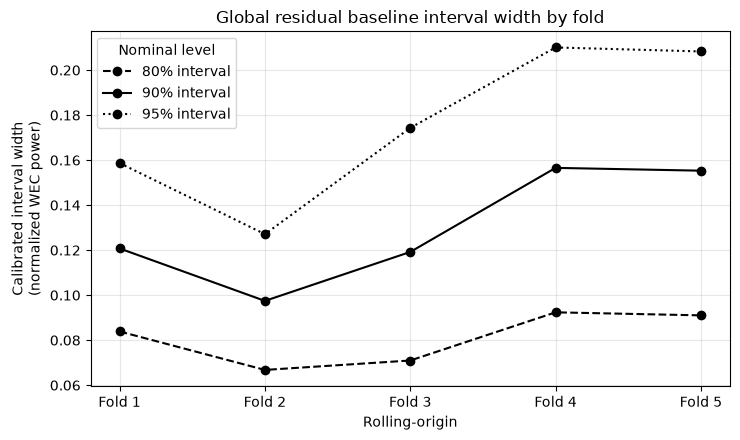

In [17]:
global_interval_params = []

for interval_level in INTERVAL_LEVELS:
    alpha = 1.0 - interval_level

    for fold_id, calib_group in calib_df.groupby("fold_id", observed=True):
        lower_offset, upper_offset = np.quantile(
            calib_group["error_norm"].dropna(),
            [alpha / 2.0, 1.0 - alpha / 2.0],
        )

        global_interval_params.append(
            {
                "interval_method": "GlobalResidual",
                "interval_level": interval_level,
                "fold_id": fold_id,
                "lower_offset_norm": lower_offset,
                "upper_offset_norm": upper_offset,
                "offset_width_norm": upper_offset - lower_offset,
            }
        )

        test_group = test_df[test_df["fold_id"].eq(fold_id)]

        interval_parts.append(
            make_interval_rows(
                test_group,
                interval_method="GlobalResidual",
                interval_level=interval_level,
                lower_offset=lower_offset,
                upper_offset=upper_offset,
            )
        )

global_interval_params = pd.DataFrame(global_interval_params)
fig, ax = plt.subplots(figsize=(7.5, 4.5))

linestyle_map = {
    0.80: "--",
    0.90: "-",
    0.95: ":",
}

for interval_level in INTERVAL_LEVELS:
    level_df = (
        global_interval_params
        .query("interval_level == @interval_level")
        .sort_values("fold_id")
    )

    ax.plot(
        level_df["fold_id"],
        level_df["offset_width_norm"],
        color="black",
        marker="o",
        linestyle=linestyle_map[interval_level],
        label=f"{int(interval_level * 100)}% interval",
    )

ax.set_title("Global residual baseline interval width by fold")
ax.set_xlabel("Rolling-origin fold")
ax.set_ylabel("Calibrated interval width\n(normalized WEC power)")
fold_ticks = sorted(global_interval_params["fold_id"].unique())
ax.set_xlabel("Rolling-origin")
ax.set_xticks(fold_ticks)
ax.set_xticklabels([f"Fold {fold_id}" for fold_id in fold_ticks])
ax.set_xticks(sorted(global_interval_params["fold_id"].unique()))
ax.grid(True, alpha=0.3)
ax.legend(title="Nominal level")

fig.tight_layout()

global_residual_width_path = FIGURES_DIR / "global_residual_interval_width_by_fold.png"
fig.savefig(global_residual_width_path, dpi=200, bbox_inches="tight")
plt.show()

The global residual baseline gives wider intervals as the nominal coverage level increases, as expected. The calibrated widths also vary across rolling-origin folds, showing that the residual distribution changes over time. Because this baseline uses one pooled residual rule per fold, it does not yet adapt to the different uncertainty levels observed across forecast horizons or models.

### Model- and horizon-specific residual quantile intervals

This method estimates lower and upper residual quantiles separately for each fold, model, forecast horizon, and interval level.

Unlike the global residual baseline, it allows interval width and asymmetry to change with both model behaviour and forecast horizon.

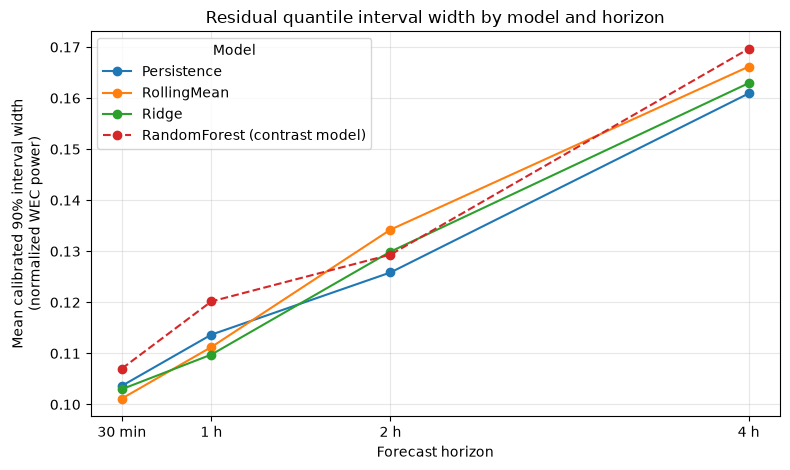

In [14]:
residual_quantile_params = []

group_cols = ["fold_id", "model", "horizon_steps"]

for interval_level in INTERVAL_LEVELS:
    alpha = 1.0 - interval_level

    for group_key, calib_group in calib_df.groupby(group_cols, observed=True):
        fold_id, model, horizon_steps = group_key

        lower_offset, upper_offset = np.quantile(
            calib_group["error_norm"].dropna(),
            [alpha / 2.0, 1.0 - alpha / 2.0],
        )

        horizon_info = (
            calib_group[["horizon_hours", "horizon_label"]]
            .drop_duplicates()
            .iloc[0]
        )

        residual_quantile_params.append(
            {
                "interval_method": "ResidualQuantile_ModelHorizon",
                "interval_level": interval_level,
                "fold_id": fold_id,
                "model": model,
                "horizon_steps": horizon_steps,
                "horizon_hours": horizon_info["horizon_hours"],
                "horizon_label": horizon_info["horizon_label"],
                "lower_offset_norm": lower_offset,
                "upper_offset_norm": upper_offset,
                "offset_width_norm": upper_offset - lower_offset,
            }
        )

        test_group = test_df[
            test_df["fold_id"].eq(fold_id)
            & test_df["model"].eq(model)
            & test_df["horizon_steps"].eq(horizon_steps)
        ]

        interval_parts.append(
            make_interval_rows(
                test_group,
                interval_method="ResidualQuantile_ModelHorizon",
                interval_level=interval_level,
                lower_offset=lower_offset,
                upper_offset=upper_offset,
            )
        )

residual_quantile_params = pd.DataFrame(residual_quantile_params)
plot_df = (
    residual_quantile_params
    .query("interval_level == @MAIN_INTERVAL_LEVEL")
    .groupby(
        ["model", "horizon_steps", "horizon_hours", "horizon_label"],
        observed=True,
    )
    .agg(
        mean_width_norm=("offset_width_norm", "mean"),
        std_width_norm=("offset_width_norm", "std"),
    )
    .reset_index()
)

horizon_ticks = (
    plot_df[["horizon_hours", "horizon_label"]]
    .drop_duplicates()
    .sort_values("horizon_hours")
)

fig, ax = plt.subplots(figsize=(8, 4.8))

for model in ALL_MODELS:
    model_df = plot_df[plot_df["model"].eq(model)].sort_values("horizon_steps")
    if model_df.empty:
        continue

    is_contrast = model in CONTRAST_MODELS
    linestyle = "--" if is_contrast else "-"
    label = f"{model} (contrast model)" if is_contrast else model

    ax.plot(
        model_df["horizon_hours"],
        model_df["mean_width_norm"],
        marker="o",
        linestyle=linestyle,
        label=label,
    )

ax.set_title("Residual quantile interval width by model and horizon")
ax.set_xlabel("Forecast horizon")
ax.set_ylabel(
    f"Mean calibrated {int(MAIN_INTERVAL_LEVEL * 100)}% interval width\n"
    "(normalized WEC power)"
)
ax.set_xticks(horizon_ticks["horizon_hours"])
ax.set_xticklabels(horizon_ticks["horizon_label"])
ax.grid(True, alpha=0.3)
ax.legend(title="Model")

fig.tight_layout()

residual_quantile_width_path = (
    FIGURES_DIR / "residual_quantile_interval_width_by_model_horizon.png"
)
fig.savefig(residual_quantile_width_path, dpi=200, bbox_inches="tight")
plt.show()

The model- and horizon-specific residual quantile intervals widen with forecast horizon, reflecting the increasing residual spread seen in the point-forecast diagnostics. The three main models have similar calibrated widths, while RandomForest is kept only as a contrast model. Compared with the global residual baseline, this method can adapt interval width to each model and forecast horizon instead of applying one pooled residual rule across all forecasts.

### Conformal-style absolute-error intervals

This method uses the calibration absolute errors to build symmetric prediction intervals around each point forecast.

For each fold, model, forecast horizon, and interval level, it estimates a calibrated absolute-error quantile from the calibration split, then applies that value as a lower and upper correction around the test prediction.

The method is described here as conformal-style because it follows the empirical calibration idea, but the time-series setting and earlier model-selection use of the calibration block mean that the intervals should be interpreted as practical calibrated intervals rather than strict formal guarantees.

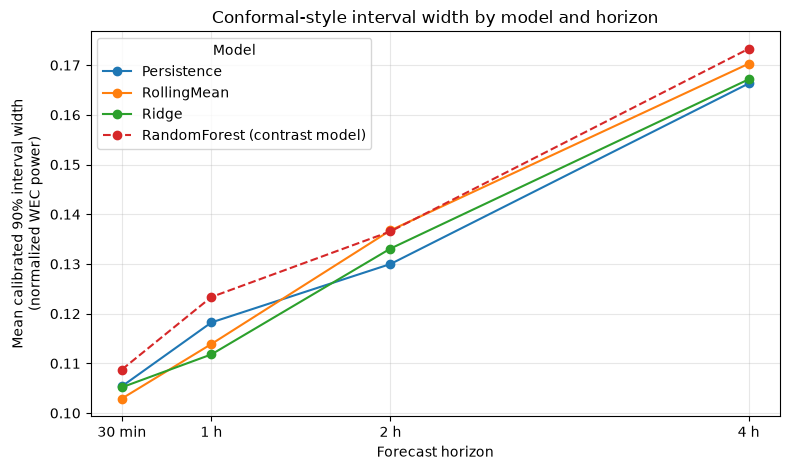

In [18]:
conformal_style_params = []

group_cols = ["fold_id", "model", "horizon_steps"]

for interval_level in INTERVAL_LEVELS:
    for group_key, calib_group in calib_df.groupby(group_cols, observed=True):
        fold_id, model, horizon_steps = group_key

        q_abs_error = conformal_style_quantile(
            calib_group["abs_error_norm"],
            interval_level=interval_level,
        )

        horizon_info = (
            calib_group[["horizon_hours", "horizon_label"]]
            .drop_duplicates()
            .iloc[0]
        )

        conformal_style_params.append(
            {
                "interval_method": "ConformalStyle_ModelHorizon",
                "interval_level": interval_level,
                "fold_id": fold_id,
                "model": model,
                "horizon_steps": horizon_steps,
                "horizon_hours": horizon_info["horizon_hours"],
                "horizon_label": horizon_info["horizon_label"],
                "q_abs_error_norm": q_abs_error,
                "offset_width_norm": 2.0 * q_abs_error,
            }
        )

        test_group = test_df[
            test_df["fold_id"].eq(fold_id)
            & test_df["model"].eq(model)
            & test_df["horizon_steps"].eq(horizon_steps)
        ]

        interval_parts.append(
            make_interval_rows(
                test_group,
                interval_method="ConformalStyle_ModelHorizon",
                interval_level=interval_level,
                lower_offset=-q_abs_error,
                upper_offset=q_abs_error,
            )
        )

conformal_style_params = pd.DataFrame(conformal_style_params)

plot_df = (
    conformal_style_params
    .query("interval_level == @MAIN_INTERVAL_LEVEL")
    .groupby(
        ["model", "horizon_steps", "horizon_hours", "horizon_label"],
        observed=True,
    )
    .agg(
        mean_width_norm=("offset_width_norm", "mean"),
        std_width_norm=("offset_width_norm", "std"),
    )
    .reset_index()
)

horizon_ticks = (
    plot_df[["horizon_hours", "horizon_label"]]
    .drop_duplicates()
    .sort_values("horizon_hours")
)

fig, ax = plt.subplots(figsize=(8, 4.8))

for model in ALL_MODELS:
    model_df = plot_df[plot_df["model"].eq(model)].sort_values("horizon_steps")
    if model_df.empty:
        continue

    is_contrast = model in CONTRAST_MODELS
    linestyle = "--" if is_contrast else "-"
    label = f"{model} (contrast model)" if is_contrast else model

    ax.plot(
        model_df["horizon_hours"],
        model_df["mean_width_norm"],
        marker="o",
        linestyle=linestyle,
        label=label,
    )

ax.set_title("Conformal-style interval width by model and horizon")
ax.set_xlabel("Forecast horizon")
ax.set_ylabel(
    f"Mean calibrated {int(MAIN_INTERVAL_LEVEL * 100)}% interval width\n"
    "(normalized WEC power)"
)
ax.set_xticks(horizon_ticks["horizon_hours"])
ax.set_xticklabels(horizon_ticks["horizon_label"])
ax.grid(True, alpha=0.3)
ax.legend(title="Model")

fig.tight_layout()

conformal_style_width_path = (
    FIGURES_DIR / "conformal_style_interval_width_by_model_horizon.png"
)
fig.savefig(conformal_style_width_path, dpi=200, bbox_inches="tight")
plt.show()

The conformal-style intervals show the same horizon-dependent widening pattern as the residual quantile intervals. This is expected because both methods are calibrated from the same fold-specific residual behaviour, but the conformal-style method uses absolute errors and therefore produces symmetric intervals around the point forecast.

The main models again have similar calibrated widths, while RandomForest remains slightly wider and is kept only as a contrast model. These intervals are practical empirical intervals rather than formal guarantees, but they provide a simple calibrated uncertainty baseline for final test-set evaluation.

### KDE residual-distribution intervals

This optional method estimates a smooth residual distribution from the calibration residuals for each fold, model, horizon, and interval level.

The method is still residual-based: it does not retrain the forecasting models or introduce new predictors. Instead, it fits a one-dimensional scikit-learn `KernelDensity` estimator to the calibration residuals, then extracts lower and upper residual quantiles from the smoothed distribution using a numerical CDF grid.

A fixed bandwidth of `0.01` normalized power is used for this lightweight comparison. This corresponds to smoothing over about 1% of the normalized WEC-power range, or about 2.5 kW on the 250 kW interpretation scale. The bandwidth is not tuned; it is chosen to keep the KDE comparison simple and avoid turning this notebook into a bandwidth-selection study.

Compared with direct residual quantiles, KDE can reduce the discreteness of empirical quantiles by smoothing the residual distribution. However, it still introduces a bandwidth choice and should therefore be interpreted as a lightweight distribution-smoothed comparison rather than a more authoritative uncertainty method.

The simpler residual quantile and conformal-style intervals remain the main empirical interval baselines.


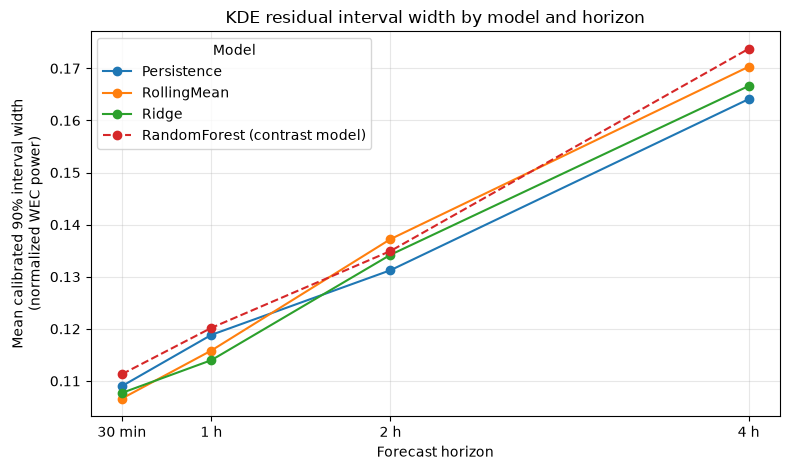

In [23]:
from sklearn.neighbors import KernelDensity

def kde_residual_quantiles(values, probs, grid_size=2048):
    """Estimate residual quantiles from a scikit-learn KDE with Silverman bandwidth."""
    values = np.asarray(pd.Series(values).dropna(), dtype=float)

    if len(values) < 20 or np.std(values) == 0:
        return np.quantile(values, probs)

    values_2d = values.reshape(-1, 1)

    kde = KernelDensity(kernel="gaussian", bandwidth=0.01)
    kde.fit(values_2d)

    bandwidth = getattr(kde, "bandwidth_", np.std(values))

    grid_margin = 4.0 * bandwidth
    grid_min = values.min() - grid_margin
    grid_max = values.max() + grid_margin
    grid = np.linspace(grid_min, grid_max, grid_size)

    density = np.exp(kde.score_samples(grid.reshape(-1, 1)))

    cdf = np.cumsum((density[:-1] + density[1:]) / 2.0 * np.diff(grid))
    cdf = np.insert(cdf, 0, 0.0)

    if cdf[-1] <= 0 or not np.isfinite(cdf[-1]):
        return np.quantile(values, probs)

    cdf = cdf / cdf[-1]

    return np.interp(probs, cdf, grid)

kde_residual_params = []

group_cols = ["fold_id", "model", "horizon_steps"]

for interval_level in INTERVAL_LEVELS:
    alpha = 1.0 - interval_level

    for group_key, calib_group in calib_df.groupby(group_cols, observed=True):
        fold_id, model, horizon_steps = group_key

        lower_offset, upper_offset = kde_residual_quantiles(
            calib_group["error_norm"],
            probs=[alpha / 2.0, 1.0 - alpha / 2.0],
        )

        horizon_info = (
            calib_group[["horizon_hours", "horizon_label"]]
            .drop_duplicates()
            .iloc[0]
        )

        kde_residual_params.append(
            {
                "interval_method": "KDEResidual_ModelHorizon",
                "interval_level": interval_level,
                "fold_id": fold_id,
                "model": model,
                "horizon_steps": horizon_steps,
                "horizon_hours": horizon_info["horizon_hours"],
                "horizon_label": horizon_info["horizon_label"],
                "lower_offset_norm": lower_offset,
                "upper_offset_norm": upper_offset,
                "offset_width_norm": upper_offset - lower_offset,
            }
        )

        test_group = test_df[
            test_df["fold_id"].eq(fold_id)
            & test_df["model"].eq(model)
            & test_df["horizon_steps"].eq(horizon_steps)
        ]

        interval_parts.append(
            make_interval_rows(
                test_group,
                interval_method="KDEResidual_ModelHorizon",
                interval_level=interval_level,
                lower_offset=lower_offset,
                upper_offset=upper_offset,
            )
        )

kde_residual_params = pd.DataFrame(kde_residual_params)

plot_df = (
    kde_residual_params
    .query("interval_level == @MAIN_INTERVAL_LEVEL")
    .groupby(
        ["model", "horizon_steps", "horizon_hours", "horizon_label"],
        observed=True,
    )
    .agg(
        mean_width_norm=("offset_width_norm", "mean"),
        std_width_norm=("offset_width_norm", "std"),
    )
    .reset_index()
)

horizon_ticks = (
    plot_df[["horizon_hours", "horizon_label"]]
    .drop_duplicates()
    .sort_values("horizon_hours")
)

fig, ax = plt.subplots(figsize=(8, 4.8))

for model in ALL_MODELS:
    model_df = plot_df[plot_df["model"].eq(model)].sort_values("horizon_steps")
    if model_df.empty:
        continue

    is_contrast = model in CONTRAST_MODELS
    linestyle = "--" if is_contrast else "-"
    label = f"{model} (contrast model)" if is_contrast else model

    ax.plot(
        model_df["horizon_hours"],
        model_df["mean_width_norm"],
        marker="o",
        linestyle=linestyle,
        label=label,
    )

ax.set_title("KDE residual interval width by model and horizon")
ax.set_xlabel("Forecast horizon")
ax.set_ylabel(
    f"Mean calibrated {int(MAIN_INTERVAL_LEVEL * 100)}% interval width\n"
    "(normalized WEC power)"
)
ax.set_xticks(horizon_ticks["horizon_hours"])
ax.set_xticklabels(horizon_ticks["horizon_label"])
ax.grid(True, alpha=0.3)
ax.legend(title="Model")

fig.tight_layout()

kde_residual_width_path = (
    FIGURES_DIR / "kde_residual_interval_width_by_model_horizon.png"
)
fig.savefig(kde_residual_width_path, dpi=200, bbox_inches="tight")
plt.show()

The KDE residual intervals show a similar horizon-dependent widening pattern to the residual quantile and conformal-style intervals. With the fixed bandwidth used here, KDE behaves as a reasonable smoothed-residual comparison rather than producing excessively wide intervals.

Because this method depends on a bandwidth choice, it remains secondary to the simpler empirical interval methods. Its main role is to check whether smoothing the calibration residual distribution changes the interval-width pattern in a meaningful way.